In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import copy

Task 1

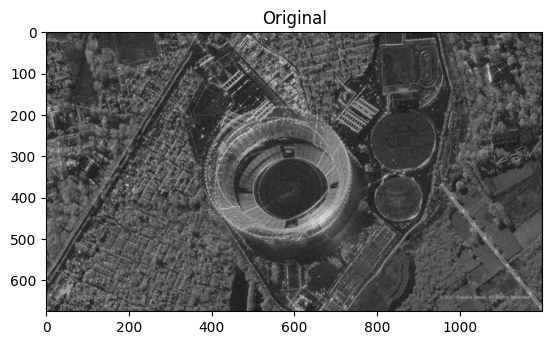

In [17]:
image = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.show()

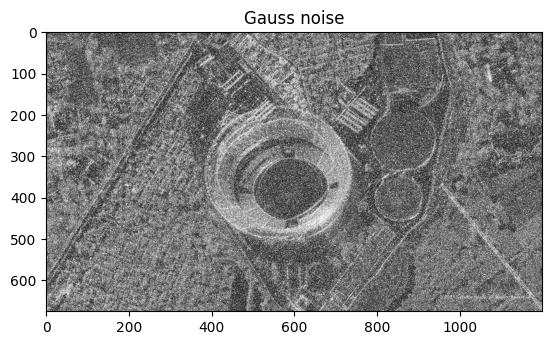

In [18]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image,noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")
plt.title('Gauss noise')
plt.show()

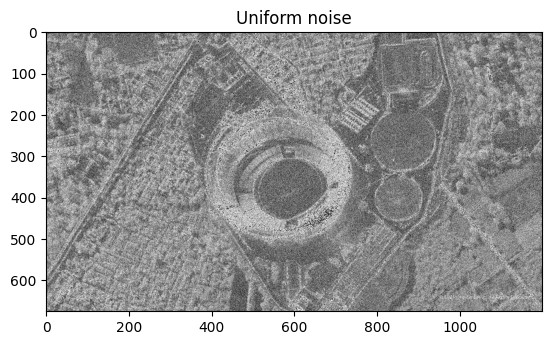

In [19]:
a = 0
b = 120

height, width = image.shape
noise = np.random.uniform(a, b, (height, width))

noisy_image = image.astype(np.float32) + noise
noisy_image = noisy_image.astype(np.uint8)

plt.imshow(noisy_image, cmap="gray")
plt.title("Uniform noise")
plt.show()

Task 2

Median 5x5: MSE=702.92, SSIM=0.4686
Gaussian 3x3: MSE=1904.32, SSIM=0.4408
Bilateral 50: MSE=2662.84, SSIM=0.2276
NLM h=20: MSE=4231.90, SSIM=0.1877

--- Gaussian noise results ---
Best by MSE: Median 5x5 (MSE=702.92, SSIM=0.4686)
Best by SSIM: Median 5x5 (MSE=702.92, SSIM=0.4686)


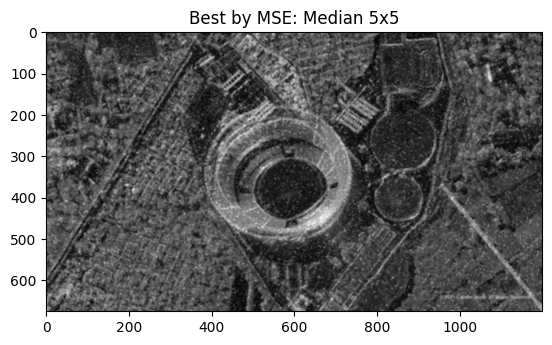

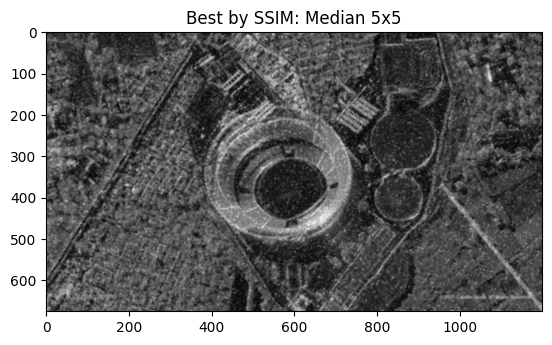

In [22]:
image_gauss_median5 = cv2.medianBlur(image_noise_gauss, 5)
image_gauss_gauss3 = cv2.GaussianBlur(image_noise_gauss, (3, 3), 0)
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 50, 50)
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)

filters_gauss = [
    ('Median 5x5', image_gauss_median5),
    ('Gaussian 3x3', image_gauss_gauss3),
    ('Bilateral 50', image_gauss_bilat),
    ('NLM h=20', image_gauss_nlm)
]

best_mse = float('inf')
best_mse_filter = ""
best_mse_image = None
best_mse_ssim = None

best_ssim = -1
best_ssim_filter = ""
best_ssim_image = None
best_ssim_mse = None

for name, filtered_image in filters_gauss:
    mse = mean_squared_error(image, filtered_image)
    ssim = structural_similarity(image, filtered_image)

    print(f"{name}: MSE={mse:.2f}, SSIM={ssim:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_mse_filter = name
        best_mse_image = filtered_image
        best_mse_ssim = ssim

    if ssim > best_ssim:
        best_ssim = ssim
        best_ssim_filter = name
        best_ssim_image = filtered_image
        best_ssim_mse = mse

print(f"\n--- Gaussian noise results ---")
print(f"Best by MSE: {best_mse_filter} (MSE={best_mse:.2f}, SSIM={best_mse_ssim:.4f})")
print(f"Best by SSIM: {best_ssim_filter} (MSE={best_ssim_mse:.2f}, SSIM={best_ssim:.4f})")

plt.imshow(best_mse_image, cmap='gray')
plt.title(f'Best by MSE: {best_mse_filter}')
plt.show()

plt.imshow(best_ssim_image, cmap='gray')
plt.title(f'Best by SSIM: {best_ssim_filter}')
plt.show()

Median 5x5: MSE=3756.48, SSIM=0.3846
Gaussian 3x3: MSE=3676.85, SSIM=0.4723
Bilateral 50: MSE=3939.20, SSIM=0.3809
NLM h=20: MSE=4477.87, SSIM=0.2869

--- Constant noise results ---
Best by MSE: Gaussian 3x3 (MSE=3676.85, SSIM=0.4723)
Best by SSIM: Gaussian 3x3 (MSE=3676.85, SSIM=0.4723)


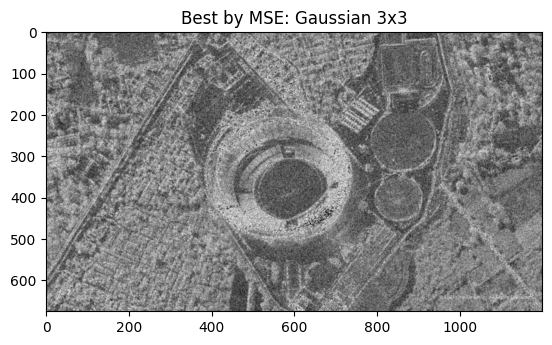

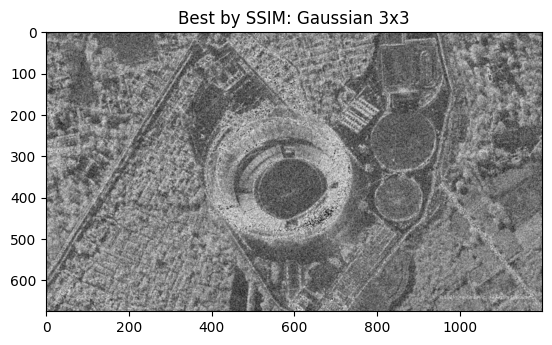

In [23]:
image_const_median5 = cv2.medianBlur(noisy_image, 5)
image_const_gauss3 = cv2.GaussianBlur(noisy_image, (3, 3), 0)
image_const_bilat = cv2.bilateralFilter(noisy_image, 9, 50, 50)
image_const_nlm = cv2.fastNlMeansDenoising(noisy_image, h=20)


filters_const = [
    ('Median 5x5', image_const_median5),
    ('Gaussian 3x3', image_const_gauss3),
    ('Bilateral 50', image_const_bilat),
    ('NLM h=20', image_const_nlm)
]

best_mse = float('inf')
best_mse_filter = ""
best_mse_image = None
best_mse_ssim = None

best_ssim = -1
best_ssim_filter = ""
best_ssim_image = None
best_ssim_mse = None

for name, filtered_image in filters_const:
    mse = mean_squared_error(image, filtered_image)
    ssim = structural_similarity(image, filtered_image)

    print(f"{name}: MSE={mse:.2f}, SSIM={ssim:.4f}")

    if mse < best_mse:
        best_mse = mse
        best_mse_filter = name
        best_mse_image = filtered_image
        best_mse_ssim = ssim

    if ssim > best_ssim:
        best_ssim = ssim
        best_ssim_filter = name
        best_ssim_image = filtered_image
        best_ssim_mse = mse

print(f"\n--- Constant noise results ---")
print(f"Best by MSE: {best_mse_filter} (MSE={best_mse:.2f}, SSIM={best_mse_ssim:.4f})")
print(f"Best by SSIM: {best_ssim_filter} (MSE={best_ssim_mse:.2f}, SSIM={best_ssim:.4f})")

plt.imshow(best_mse_image, cmap='gray')
plt.title(f'Best by MSE: {best_mse_filter}')
plt.show()

plt.imshow(best_ssim_image, cmap='gray')
plt.title(f'Best by SSIM: {best_ssim_filter}')
plt.show()